# Важное

Для второго пункта мы не сделали: 1)удалить аномальные значения 2) Сформировать дополнительный столбец 3) Провести аналитический и графический анализ данных


# Пункт 2

In [ ]:
import pandas as pd
import numpy as np

# Сброс ограничений на количество выводимых рядов
pd.set_option('display.max_rows', None)
 
# Сброс ограничений на число столбцов
pd.set_option('display.max_columns', None)
 
# Сброс ограничений на количество символов в записи
pd.set_option('display.max_colwidth', None)

data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace(',', '')
data['развитие_опп']=data['развитие_опп'].map({'нет':0,'есть':1})

#исправил столбец чсс с object на int
data["чсс"] = data["чсс"].apply(lambda x: 70 if x == "7o" else x)
data['чсс'] = data['чсс'].astype(int)

#исправил столбец рн с object на float
data['рн'] = data['рн'].apply(lambda x: float(x.replace(",", ".")) if "," in x else float(x))
data['рн'] = data['рн'].astype(float)

#редактирование выбросов
# def vibros(x):
#     if (len(list(x.unique()))>2):
#         q75, q25 = np.percentile(x.tolist(), [75, 25])
#         H = q75 - q25
#         data_rn_clear = x[(q25 - 3 * H <= x) & (x <= q75 + 3 * H)]

# int_columns = data.select_dtypes(include='int').columns
# data[int_columns] = data[int_columns].apply(lambda x: vibros(x))

# float_columns = data.select_dtypes(include='float').columns
# data[float_columns] = data[float_columns].apply(lambda x: vibros(x))

#столбец с людьми использовавшими АИК
# data
#print(data[data["аик"] == 1]['аик'])


#замена пропусков на median
# print(data.isnull().sum().sum()) команда считающая количество Nan
columns_types_series = data.dtypes # все типы столбцов в виде series
count = 0
for i in data.columns:
    if columns_types_series[count] != "object": #заполняем все пропуски на медиану, кроме столбцов object
        data[i] = data[i].fillna(data[i].median())
    count += 1

#удаление явных дубликатов, но я не проверил, удалились ли дубликаты
data = data.drop_duplicates()

# 3.1

In [ ]:
# data['хбп']=data['хбп'].map({'Пациенты без ХБП':0,'Стадия C1-C2':1,'Стадия C3':2})
# def check(a,b):
#     if b>=90 and a!=0:
#         return True
#     elif 90>b>=60 and a!=1:
#         return True
#     elif 60>b>=30 and a!=2:
#         return True
#     return False

# def need(a,b):
#     if b>=90 and a!=0:
#         return 0
#     elif 90>b>=60 and a!=1:
#         return 1
#     elif 60>b>=30 and a!=2:
#         return 2
#     return 3
# k=0
# for index, row in data.iterrows():
#     a=data.loc[index,'хбп']
#     b=data.loc[index,'скф_расч.']
#     if check(a,b):
#         k+=1
#         data.loc[index,'хбп']=need(a,b)



print(str(round(len(data[(data["развитие_опп"] == 1) & (data["хбп"] != "Пациенты без ХБП")]) / len(data['хбп']) * 100, 2)) + "% пациентов с хронической болезнью почек с ОПП")
print(str(round(len(data[(data["развитие_опп"] != 1) & (data["хбп"] != "Пациенты без ХБП")]) / len(data["хбп"]) * 100, 2)) + "% пациентов с хронической болезнью почек без ОПП")
print(str(round(len(data[(data["развитие_опп"] == 1) & (data["сахарный_диабет"] == 1)]) / len(data["сахарный_диабет"]) * 100, 2)) + "% пациентов с cахарным диабетом без ОПП")
print(str(round(len(data[(data["развитие_опп"] != 1) & (data["сахарный_диабет"] == 1)]) / len(data["сахарный_диабет"]) * 100, 2)) + "% пациентов с cахарным диабетом с ОПП")
print(str(round(len(data[(data["развитие_опп"] == 1) & (data["гб"] == 1)]) / len(data["сахарный_диабет"]) * 100, 2)) + "% пациентов с наличием гипертонической болезни с ОПП")
print(str(round(len(data[(data["развитие_опп"] != 1) & (data["гб"] == 1)]) / len(data["сахарный_диабет"]) * 100, 2)) + "% пациентов с наличием гипертонической болезни без ОПП")

35.18% пациентов с хронической болезнью почек с ОПП
19.1% пациентов с хронической болезнью почек без ОПП
21.61% пациентов с cахарным диабетом без ОПП
11.56% пациентов с cахарным диабетом с ОПП
54.27% пациентов с наличием гипертонической болезни с ОПП
34.17% пациентов с наличием гипертонической болезни без ОПП


# 3.3

Я разными способами рассматривал этот пункт и ответ: не зависит 

In [ ]:
#data.dtypes
s1 = data["длительность_операции"]
s2 = data["инфаркт_миокарда"]
df33 = pd.concat([s1, s2], axis=1)
df33.corr(method='spearman')

,длительность_операции,инфаркт_миокарда
длительность_операции,1.000000,-0.028518
инфаркт_миокарда,-0.028518,1.000000


ShapiroResult(statistic=0.9764837026596069, pvalue=0.022451916709542274)
131


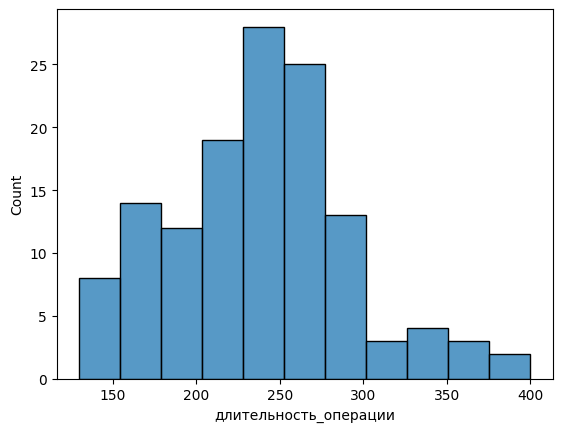

In [ ]:
import seaborn as sns
from scipy.stats import shapiro
sns.histplot(data[data["инфаркт_миокарда"] == 1]["длительность_операции"])
print(shapiro(data[data["инфаркт_миокарда"] == 1]["длительность_операции"]))
print(len(data[data["инфаркт_миокарда"] == 1]["длительность_операции"]))


<AxesSubplot: xlabel='инфаркт_миокарда', ylabel='длительность_операции'>

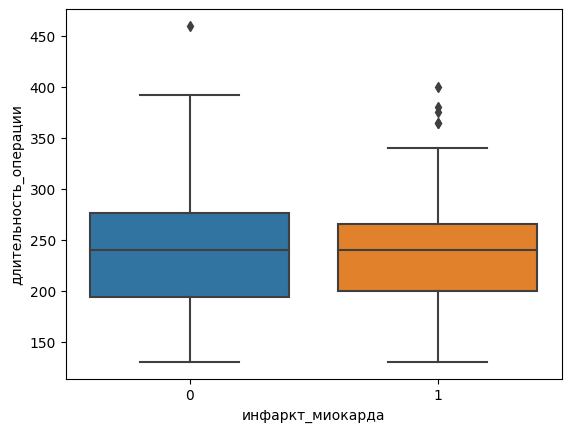

In [ ]:
import seaborn as sns
sns.boxplot(x=data["инфаркт_миокарда"], y=data["длительность_операции"])

ShapiroResult(statistic=0.9569971561431885, pvalue=0.01959223672747612)
68


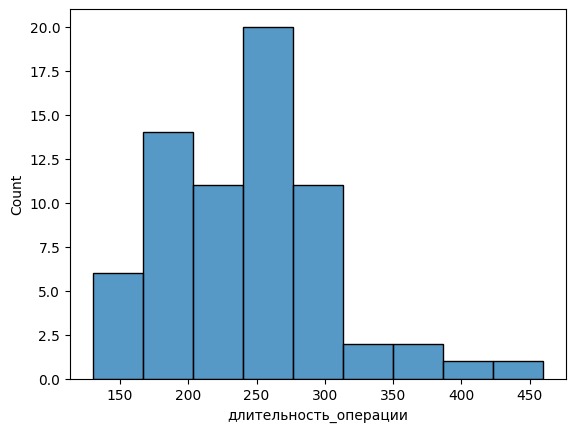

In [ ]:
import seaborn as sns
sns.histplot(data[data["инфаркт_миокарда"] != 1]["длительность_операции"])
print(shapiro(data[data["инфаркт_миокарда"] != 1]["длительность_операции"]))
print(len(data[data["инфаркт_миокарда"] == 0]["длительность_операции"]))

In [ ]:
import scipy.stats as stats

#perform the Mann-Whitney U test
print(stats.mannwhitneyu (data[data["инфаркт_миокарда"] != 1]["длительность_операции"],data[data["инфаркт_миокарда"] == 1]["длительность_операции"], alternative='two-sided'))

MannwhitneyuResult(statistic=4608.5, pvalue=0.6891624580027408)


In [ ]:
import pandas as pd
data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data["АИК"]

0      0
1      1
2      0
3      1
4      1
5      1
6      1
7      1
8      1
9      1
10     1
11     1
12     0
13     0
14     1
15     1
16     0
17     1
18     1
19     1
20     1
21     0
22     0
23     1
24     1
25     1
26     1
27     1
28     1
29     1
30     1
31     1
32     1
33     0
34     1
35     1
36     1
37     1
38     0
39     0
40     0
41     0
42     1
43     0
44     1
45     1
46     1
47     1
48     1
49     1
50     1
51     1
52     1
53     1
54     1
55     1
56     0
57     1
58     1
59     1
60     1
61     1
62     0
63     1
64     0
65     1
66     0
67     1
68     1
69     1
70     0
71     1
72     1
73     1
74     1
75     0
76     1
77     1
78     0
79     1
80     0
81     1
82     1
83     0
84     0
85     0
86     1
87     1
88     1
89     1
90     1
91     0
92     1
93     1
94     1
95     1
96     1
97     1
98     1
99     1
100    1
101    1
102    1
103    1
104    1
105    1
106    1
107    1
108    1
109    0
110    1
1

# Пункт 1

In [ ]:
import pandas as pd
data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace(',', '')
data['развитие_опп']=data['развитие_опп'].map({'нет':0,'есть':1})

data.info()
print(data)
print('hi')

10                        3.7    57    16        5.48          0.85   1.31   
11                        4.0    30    33        5.00          1.64   1.00   
12                        3.2    50    31        5.64          3.23   1.48   
13                        3.7    11    26        5.29          2.12   1.14   
14                        4.0    24    22        2.62          0.50   1.00   
15                        4.3    22    33        5.37          2.74   1.21   
16                        4.0     8    15        4.30          1.70   1.00   
17                        4.6    85    45        6.14          2.23   1.04   
18                        3.7    25    22        4.10          0.99   0.92   
19                        4.2    24    10        2.77          1.82   0.77   
20                        4.5    19    25        4.39          2.13   0.98   
21                        4.4    15    12        6.00          3.12   0.80   
22                        4.5    37    19        5.80          2

# 3.6 3.7

In [ ]:
import pandas as pd
import numpy as np


data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace(',', '')
#//////////////////////
new=data[['хбп','скф_расч.','пол']]
new['хбп']=new['хбп'].map({'Пациенты без ХБП':0,'Стадия C1-C2':1,'Стадия C3':2})
def check(a,b):
    if b>=90 and a!=0:
        return True
    elif 90>b>=60 and a!=1:
        return True
    elif 60>b>=30 and a!=2:
        return True
    return False

def need(a,b):
    if b>=90 and a!=0:
        return 0
    elif 90>b>=60 and a!=1:
        return 1
    elif 60>b>=30 and a!=2:
        return 2
    return 3
k=0
for index, row in new.iterrows():
    a=new.loc[index,'хбп']
    b=new.loc[index,'скф_расч.']
    if check(a,b):
        k+=1
        new.loc[index,'хбп']=need(a,b)
print(f"поставлено {k} неверных диагнозов")

#////////////////////////////

correlation = round(new['хбп'].corr(new['скф_расч.']),4)
print(abs(correlation))
# Между диагнозом хбп и значением скф есть сильная т.к. параметр скф напрямую завсисит от состояния печени 
#Именно по этому показателю реальные врачи ставят диагноз.


поставлено 101 неверных диагнозов
0.8043
/tmp/ipykernel_188/224436785.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new['хбп']=new['хбп'].map({'Пациенты без ХБП':0,'Стадия C1-C2':1,'Стадия C3':2})
/shared-libs/python3.9/py/lib/python3.9/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


-0.5531
0.0551


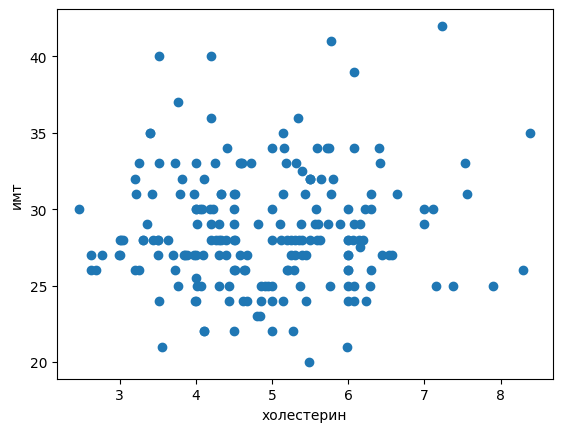

0.5496


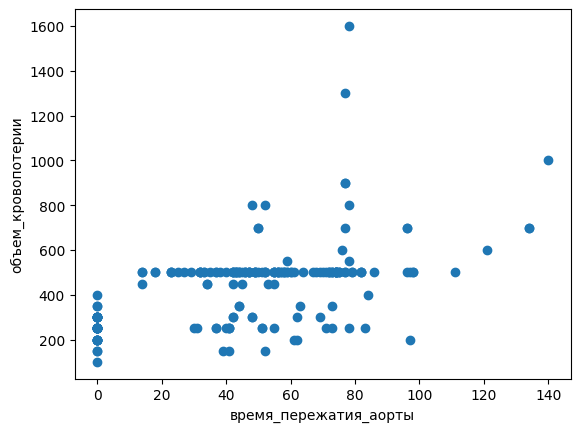

0.1291
0.0144
/tmp/ipykernel_188/2783178993.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new['развитие_опп']=new['развитие_опп'].map({'нет':0,'есть':1})


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace(',', '')

first='возраст'
second='скф_расч.'
new=data[[first,second]]
correlation = round(new[first].corr(new[second]),4)
print(correlation)
# Между возрастом и значением скф есть умеренная связь

first='холестерин'
second='имт'
new=data[[first,second]]
correlation = round(new[first].corr(new[second]),4)
print(correlation)
plt.scatter(new[first], new[second])
plt.xlabel(first)
plt.ylabel(second)
plt.show()
# Между холестерином и ИМТ слабая зависимость

first='время_пережатия_аорты'
second='объем_кровопотерии'
new=data[[first,second]]
correlation = round(new[first].corr(new[second]),4)
print(correlation)
plt.scatter(new[first], new[second])
plt.xlabel(first)
plt.ylabel(second)
plt.show()
# Между временем пережатия аорты и объёмом кровопотерии есть умеренная связь

first='аик'
second='развитие_опп'
new=data[[first,second]]

new['развитие_опп']=new['развитие_опп'].map({'нет':0,'есть':1})
correlation = round(new[first].corr(new[second]),4)
print(correlation)
# Между холестерином и ИМТ слабая зависимость
data["чсс"] = data["чсс"].apply(lambda x: 70 if x == "7o" else x)
data['чсс'] = data['чсс'].astype(int)
first='чсс'
second='хсн'
new=data[[first,second]]

correlation = round(new[first].corr(new[second]),4)
print(correlation)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace(',', '')
data['хбп']=data['хбп'].map({'Пациенты без ХБП':0,'Стадия C1-C2':1,'Стадия C3':2})
def check(a,b):
    if b>=90 and a!=0:
        return True
    elif 90>b>=60 and a!=1:
        return True
    elif 60>b>=30 and a!=2:
        return True
    return False

def need(a,b):
    if b>=90 and a!=0:
        return 0
    elif 90>b>=60 and a!=1:
        return 1
    elif 60>b>=30 and a!=2:
        return 2
    return 3

k=0
for index, row in data.iterrows():
    a=data.loc[index,'хбп']
    b=data.loc[index,'скф_расч.']
    if check(a,b):
        k+=1
        data.loc[index,'хбп']=need(a,b)

data['хбп']=data['хбп'].map({0:'Пациенты без ХБП',1:'Стадия C1-C2',2:'Стадия C3'})
df = data['хбп'].value_counts(normalize=True)
f = plt.pie(df, labels=df.index.unique(), autopct='%1.1f%%')
plt.show()


data.hist(column='возраст')
plt.show()
#наибольшая вероятность заболеть в возрасте +-60 лет
new=data[data['развитие_опп']=='есть']
new=new[new['хбп']!='Пациенты без ХБП']
new['пол']=new['пол'].map({1:'мужчины',0:'женщины'})
k = new['пол'].value_counts(normalize=True)
f = plt.pie(k, labels=k.index.unique(), autopct='%1.1f%%')
plt.show()

#мужчины болеют опп или хбп чаще

# Гипотезы

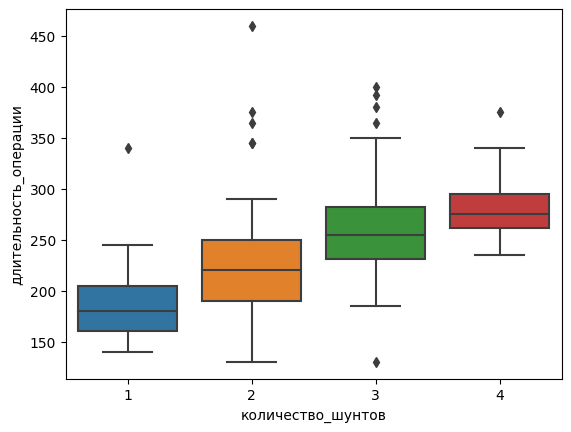

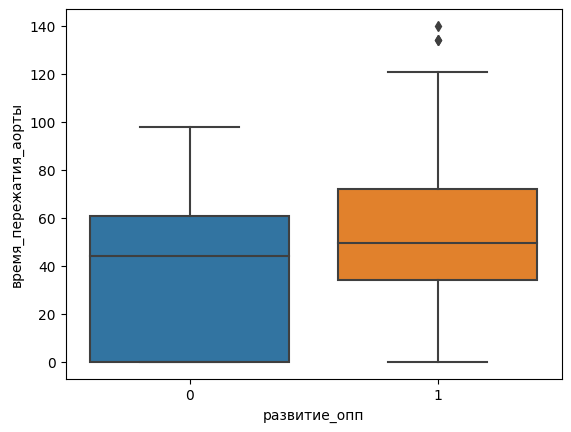

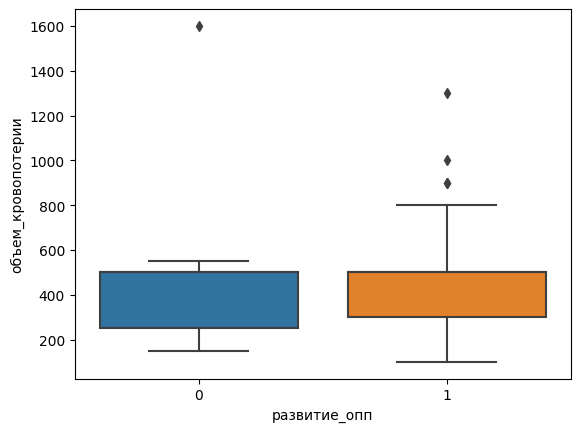

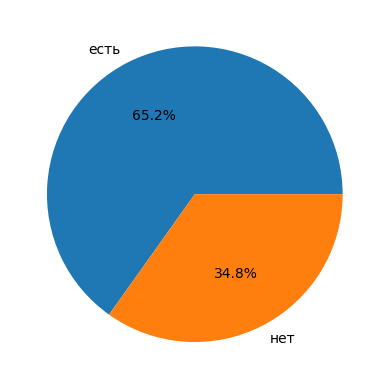

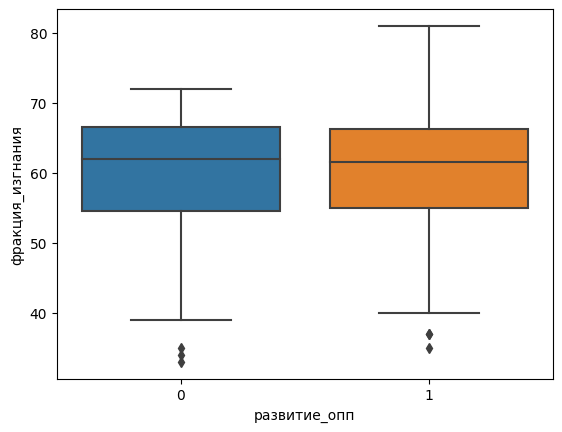

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('medics_1.csv', sep=',', skipinitialspace=True, decimal=',')
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace(',', '')
data['развитие_опп']=data['развитие_опп'].map({'нет':0,'есть':1})

#исправил столбец чсс с object на int
data["чсс"] = data["чсс"].apply(lambda x: 70 if x == "7o" else x)
data['чсс'] = data['чсс'].astype(int)

#исправил столбец рн с object на float
data['рн'] = data['рн'].apply(lambda x: float(x.replace(",", ".")) if "," in x else float(x))
data['рн'] = data['рн'].astype(float)

#столбец с людьми использовавшими АИК
data
#print(data[data["аик"] == 1]['аик'])


#замена пропусков на median
# print(data.isnull().sum().sum()) команда считающая количество Nan
columns_types_series = data.dtypes # все типы столбцов в виде series
count = 0
for i in data.columns:
    if columns_types_series[count] != "object": #заполняем все пропуски на медиану, кроме столбцов object
        data[i] = data[i].fillna(data[i].median())
    count += 1

#удаление явных дубликатов, но я не проверил, удалились ли дубликаты
data = data.drop_duplicates()



'''
по графику очевидно что чем больше шунтов накладывали тем дольше шла операция
'''

first='количество_шунтов'
second='длительность_операции'
new=data[[first,second]]
sns.boxplot(x=new[first], y=new[second])
plt.show()

'''
Время пережатия аорты увеличивает риск развитие опп
Вывод: время пережатия действительно влияет на риск развития, хотя и медиана двух групп примерно одинаковая,
у людей которые с опп длительность пережатия была больше в то время как основной части здоровых аорту
не пережимали или делали это не длительно
'''
first='развитие_опп'
second='время_пережатия_аорты'
new=data[[first,second]]

sns.boxplot(x=new[first], y=new[second])
plt.show()
'''
объём кровопотери не сильно влияет на риск развития опп,
несмотря на то что влияет на почки в целом
'''
first='развитие_опп'
second='объем_кровопотерии'
new=data[[first,second]]
sns.boxplot(x=new[first], y=new[second])
plt.show()


'''
из больных дибетом более 60% имеют опп => наличие диабета действительно влияет на риск развития опп
'''
first='развитие_опп'
second='сахарный_диабет'
new=data[[first,second]]
new=new[new['сахарный_диабет']==1]
new['развитие_опп']=new['развитие_опп'].map({0:'нет',1:'есть'})
k = new['развитие_опп'].value_counts(normalize=True)
f = plt.pie(k, labels=k.index.unique(), autopct='%1.1f%%')
plt.show()

'''
фракция изгнания практически не влияет на риск развития опп
'''
first='развитие_опп'
second='фракция_изгнания'
new=data[[first,second]]
sns.boxplot(x=new[first], y=new[second])
plt.show()





# Гипотезы Игнатова

### Гипотеза 9: Повышенный СКФ влияет на вероятность развитие ОПП.

Вывод среди людей с повышенным СКФ нет людей, у которых отсутствует ОПП.  (  >137 - повышенный СКФ) 

124


Text(0, 0.5, 'развитие_опп')

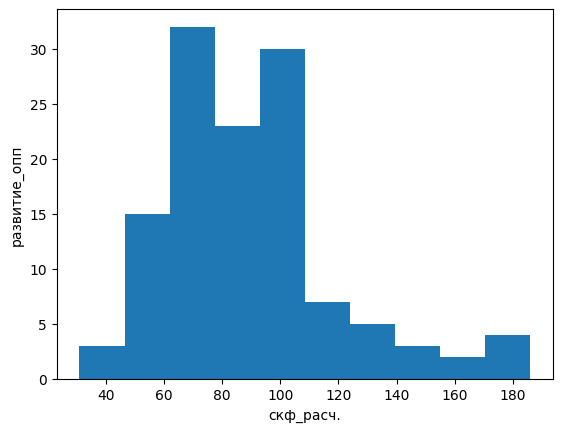

In [ ]:
print(len(data[data["развитие_опп"] == 1]['скф_расч.']))
plt.hist(data[data["развитие_опп"] == 1]['скф_расч.'])
plt.xlabel('скф_расч.')
plt.ylabel('развитие_опп')
#plt.title('Толщина паренхимы почек в зависимости от возраста')

75


(array([ 2.,  2.,  3., 19., 13., 18.,  6.,  6.,  3.,  3.]),
 array([ 31.1 ,  41.49,  51.88,  62.27,  72.66,  83.05,  93.44, 103.83,
        114.22, 124.61, 135.  ]),
 <BarContainer object of 10 artists>)

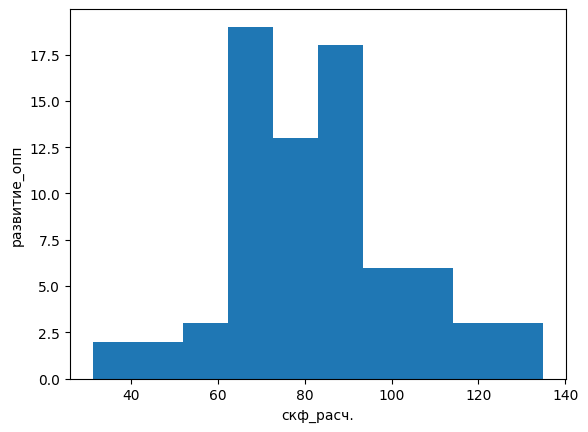

In [ ]:
print(len(data[data["развитие_опп"] == 0]['скф_расч.']))
plt.xlabel('скф_расч.')
plt.ylabel('развитие_опп')
plt.hist(data[data["развитие_опп"] == 0]['скф_расч.'])

135.0 - макс знач у ОПП = 0, 186 - макс знач у ОПП = 1

135.0
186.0


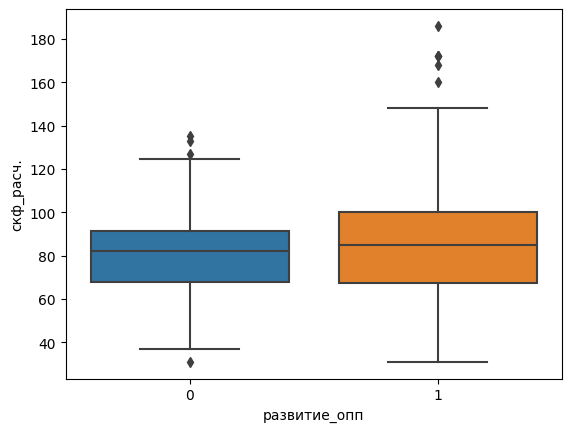

In [ ]:
sns.boxplot(data, x="развитие_опп", y='скф_расч.')
print(max(data[data["развитие_опп"] == 0]['скф_расч.']))
print(max(data[data["развитие_опп"] == 1]['скф_расч.']))

9 - количество человек у которых СКФ > 135 (такие люди есть только с ОПП)

In [ ]:
print(str(len(data[(data["развитие_опп"] == 1) & (data['скф_расч.'] > 137)])) + " - количество человек у которых СКФ > 135 (такие люди есть только с ОПП)")

9 - количество человек у которых СКФ > 135 (такие люди есть только с ОПП)


In [ ]:
from scipy import stats


print(stats.ttest_ind(data[data["развитие_опп"] == 0]['скф_расч.'], data[data["развитие_опп"] == 1]['скф_расч.']))

Ttest_indResult(statistic=-1.5207736051693905, pvalue=0.12992006862045571)


In [ ]:
from scipy.stats import mannwhitneyu

print(mannwhitneyu(data[data["развитие_опп"] == 0]['скф_расч.'], data[data["развитие_опп"] == 1]['скф_расч.']))

MannwhitneyuResult(statistic=4291.5, pvalue=0.36310858824292414)


### Гипотеза 10: РН показатель крови влияет на ОПП.

Вывод: Гипотеза не подтвердилась, РН не влияет на развитие ОПП.

(в норме 7,35 - 7,45)

График без чистки ошибочных значений

7.55
7.52


<AxesSubplot: xlabel='развитие_опп', ylabel='рн'>

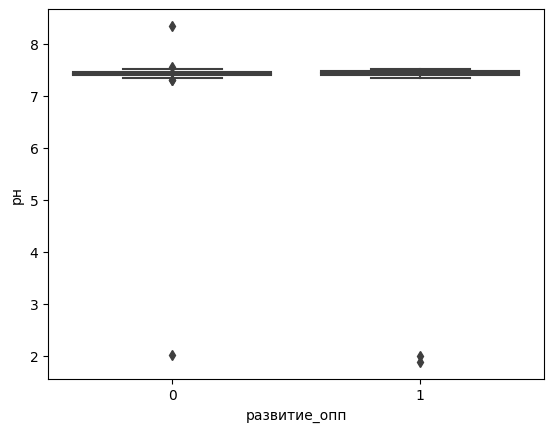

In [ ]:
import numpy as np
data["рн"].value_counts()
q75, q25 = np.percentile(data["рн"].tolist(), [75, 25])
H = q75 - q25
data_rn_clear = data[(q25 - 3 * H <= data["рн"]) & (data["рн"] <= q75 + 3 * H)]
print(max(data_rn_clear[data_rn_clear["развитие_опп"] == 0]["рн"]))
print(max(data_rn_clear[data_rn_clear["развитие_опп"] == 1]["рн"]))
sns.boxplot(data, x="развитие_опп", y='рн')

График с чисткой от ошибочных значений

<AxesSubplot: xlabel='развитие_опп', ylabel='рн'>

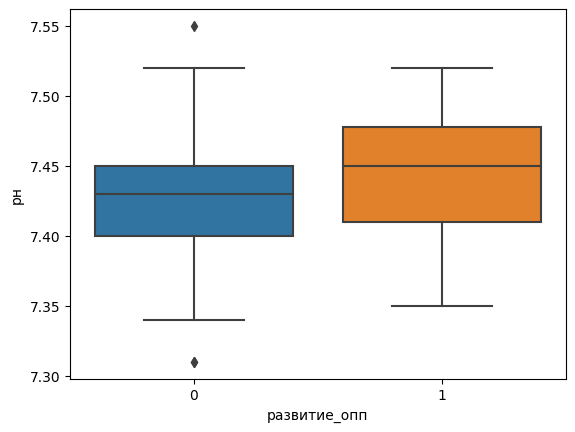

In [ ]:
sns.boxplot(data_rn_clear, x="развитие_опп", y='рн')

Поскольку pvalue < 0.05, то мы можем сказать, что рн показатель не влияет на развитие_опп

In [ ]:
print(mannwhitneyu(data_rn_clear[data_rn_clear["развитие_опп"] == 0]['рн'], data_rn_clear[data_rn_clear["развитие_опп"] == 1]['рн']))

MannwhitneyuResult(statistic=3454.0, pvalue=0.008664215047599625)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d0ceb3eb-1f51-4363-a332-ef7f5cbba9de' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>